# Healthcare Popular Times Proxy Busyness ML

本 notebook 只负责运行 pipeline、展示结果、输出图表和说明。数据构建逻辑已经拆到：

```text
Data+ML/test/6.28-7.3/src/ml_feature_pipeline.py
```

目标仍是预测 `Google Popular Times proxy busyness`，不是实测真实客流。

`rating` 现在由 SerpAPI Place results 回填到 `venues.rating`，回填完成后会在覆盖统计里重新出现。

当前特征输入优先来自 DB 规范化表（`venues`、`healthcare_profiles`、`pedestrian_ramps`），`venue_label_status_coverage_view.csv` 只保留样本锚点和覆盖统计。


## 0. Notebook 职责

- 运行离线 pipeline 生成/刷新 CSV 输出。
- 展示标签覆盖、特征覆盖、外部数据源审计、训练表规模。
- 展示输入指标与输出指标说明。
- 展示 DB 直取字段、外部静态 enrich 字段和 label-only 字段的来源归类。
- 不调用 SerpAPI live API，不写 DB，不执行 schema migration。
- 保留少量图表，方便汇报和检查。


In [1]:
from pathlib import Path
import sys

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def find_project_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / 'Data+ML').exists() and (candidate / 'docs').exists():
            return candidate
    raise FileNotFoundError('Could not locate project root.')

PROJECT_ROOT = find_project_root()
PIPELINE_SRC = PROJECT_ROOT / 'Data+ML/test/6.28-7.3/src'
OUTPUT_DIR = PROJECT_ROOT / 'Data+ML/test/6.28-7.3/output'

sys.path.insert(0, str(PIPELINE_SRC))
from ml_feature_pipeline import run_pipeline

pd.set_option('display.max_columns', 80)
pd.set_option('display.width', 160)

print('PROJECT_ROOT:', PROJECT_ROOT)
print('PIPELINE_SRC exists:', PIPELINE_SRC.exists())
print('OUTPUT_DIR:', OUTPUT_DIR)


PROJECT_ROOT: /Users/alex/Documents/COMP47360-Research_Practicum/Group6_Summer-Project
PIPELINE_SRC exists: True
OUTPUT_DIR: /Users/alex/Documents/COMP47360-Research_Practicum/Group6_Summer-Project/Data+ML/test/6.28-7.3/output


## 1. 运行 Pipeline

该步骤会读取本地静态数据、DB 导出的规范化表和 SerpAPI cache，并刷新 `output/` 下的 CSV。默认不调用外部 API。


In [2]:
outputs = run_pipeline(PROJECT_ROOT)
manifest = pd.read_csv(outputs['manifest'])
manifest


/Users/alex/Documents/COMP47360-Research_Practicum/Group6_Summer-Project/Data+ML/test/6.28-7.3/src/ml_feature_pipeline.py:489: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql_query(query, conn)
/Users/alex/Documents/COMP47360-Research_Practicum/Group6_Summer-Project/Data+ML/test/6.28-7.3/src/ml_feature_pipeline.py:489: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql_query(query, conn)


,name,path,rows
0,status_breakdown,/Users/alex/Documents/COMP47360-Research_Pract...,3
1,coverage_summary,/Users/alex/Documents/COMP47360-Research_Pract...,1
2,feature_registry,/Users/alex/Documents/COMP47360-Research_Pract...,28
3,popular_times,/Users/alex/Documents/COMP47360-Research_Pract...,16090
4,popular_times_summary,/Users/alex/Documents/COMP47360-Research_Pract...,1
5,place_features,/Users/alex/Documents/COMP47360-Research_Pract...,490
6,spatial_features,/Users/alex/Documents/COMP47360-Research_Pract...,1086
7,spatial_audit,/Users/alex/Documents/COMP47360-Research_Pract...,4
8,urban_activity_features,/Users/alex/Documents/COMP47360-Research_Pract...,1086
9,urban_activity_audit,/Users/alex/Documents/COMP47360-Research_Pract...,1


## 2. 读取输出结果


In [3]:

def read_output(name: str) -> pd.DataFrame:
    return pd.read_csv(OUTPUT_DIR / name, low_memory=False)

coverage_summary = read_output('coverage_summary.csv')
label_status = read_output('label_status_breakdown.csv')
feature_registry = read_output('feature_registry.csv')
popular_times_summary = read_output('popular_times_summary.csv')
training_summary = read_output('training_frame_summary.csv')
feature_coverage = read_output('feature_coverage_summary.csv')
training_row_feature_coverage = read_output('training_row_feature_coverage_summary.csv')
venue_feature_coverage = read_output('venue_static_feature_coverage_summary.csv')
spatial_audit = read_output('spatial_features_v1_audit.csv')
source_audit = read_output('healthcare_external_source_audit_v1.csv')
db_feature_source_audit = read_output('db_feature_source_audit.csv')
capacity_match_audit = read_output('healthcare_external_match_audit_v1.csv')
io_dictionary = read_output('input_output_field_dictionary.csv')
training_frame = read_output('ml_training_frame_v1.csv')
seasonal_baseline = read_output('seasonal_baseline.csv')
model_metrics = read_output('model_metrics_v1.csv')
model_predictions = read_output('model_test_predictions_v1.csv')
prediction_curve = read_output('prediction_curve_v1.csv')
ablation_summary = read_output('ablation_summary_v1.csv')
low_coverage_imputation = read_output('low_coverage_imputation_diagnostics_v1.csv')
low_coverage_drop_one = read_output('low_coverage_drop_one_ablation_v1.csv')

print('loaded outputs from', OUTPUT_DIR)


loaded outputs from /Users/alex/Documents/COMP47360-Research_Practicum/Group6_Summer-Project/Data+ML/test/6.28-7.3/output


## 3. 标签覆盖与训练规模


In [4]:
display(coverage_summary)
display(popular_times_summary)
display(training_summary)
if {'metric', 'value'}.issubset(coverage_summary.columns):
    healthcare_positive = int(coverage_summary.loc[coverage_summary['metric'].eq('healthcare_has_popular_times'), 'value'].iloc[0])
else:
    healthcare_positive = int(coverage_summary['has_popular_times'].iloc[0])

if {'metric', 'value'}.issubset(popular_times_summary.columns):
    unique_groups = int(popular_times_summary.loc[popular_times_summary['metric'].eq('unique_prediction_groups'), 'value'].iloc[0])
else:
    unique_groups = int(popular_times_summary['unique_prediction_groups'].iloc[0])
print(f"{healthcare_positive}: healthcare venues labeled as has_popular_times")
print(f"{unique_groups}: unique SerpAPI place IDs with parseable hourly popular-times data")


,healthcare_total,serpapi_matched,has_popular_times,no_popular_times,search_not_matched,trainable_pct
0,1086,743,161,582,343,14.8


,json_files_with_rows,hourly_rows,unique_prediction_groups,min_hour,max_hour,busyness_min,busyness_max
0,130,16090,121,0,23,0,100


,metric,value
0,training_rows,22645
1,unique_prediction_groups,121
2,unique_venues,164
3,busyness_score_min,0
4,busyness_score_max,100
5,split_rows_train,15823
6,split_rows_val,3774
7,split_rows_test,3048


161: healthcare venues labeled as has_popular_times
121: unique SerpAPI place IDs with parseable hourly popular-times data


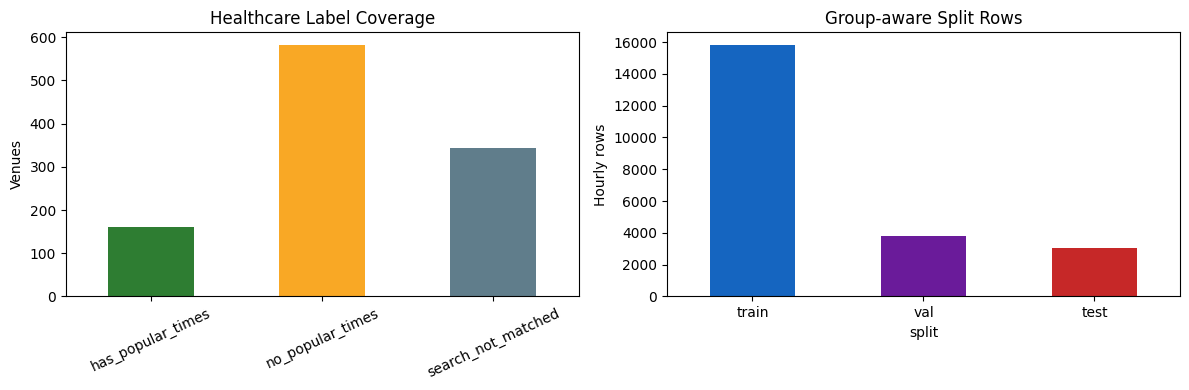

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

healthcare_counts = coverage_summary.iloc[0][['has_popular_times', 'no_popular_times', 'search_not_matched']]
healthcare_counts.plot(kind='bar', ax=axes[0], color=['#2E7D32', '#F9A825', '#607D8B'])
axes[0].set_title('Healthcare Label Coverage')
axes[0].set_ylabel('Venues')
axes[0].tick_params(axis='x', rotation=25)

split_counts = training_frame['split'].value_counts().reindex(['train', 'val', 'test']).fillna(0)
split_counts.plot(kind='bar', ax=axes[1], color=['#1565C0', '#6A1B9A', '#C62828'])
axes[1].set_title('Group-aware Split Rows')
axes[1].set_ylabel('Hourly rows')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()



## 4. 特征登记与覆盖率

主覆盖率表 `feature_coverage_summary.csv` 只包含 `feature_registry.csv` 中登记的 25 个模型/输入特征。

每个特征按自身 `scope` 选择正确分母：

- `venue_static`: 分母是一行一个 healthcare venue。
- `training_row`: 分母是 `venue × day × hour` 的训练样本行。

动态特征只包括：`traffic_score`、`is_business_hours`、`mta_hourly_ridership`、`citibike_station_activity`、`nyc_traffic_hourly_volume`、`urban_activity_proxy_score`。其中 `traffic_score` 当前由 `busyness_score` proxy 映射。

`venue_static_feature_coverage_summary.csv` 和 `training_row_feature_coverage_summary.csv` 仅作为诊断明细，不混入主特征覆盖率表。


In [6]:

# 主表：严格限制为 feature_registry 的 25 个特征。
display(feature_coverage.sort_values(['scope', 'coverage_pct'], ascending=[True, False]))

print('Diagnostic: venue static coverage detail')
display(venue_feature_coverage.sort_values('coverage_pct', ascending=False))

print('Diagnostic: dynamic feature coverage detail')
display(training_row_feature_coverage.sort_values('coverage_pct', ascending=False))


,feature,scope,dtype,non_null_rows,total_rows,coverage_pct,status,coverage_basis,source_column
6,traffic_score,training_row,int,22645,22645,100.0,ok,training row,busyness_score
12,is_business_hours,training_row,bool,22645,22645,100.0,ok,training row,is_business_hours
24,mta_hourly_ridership,training_row,missing,0,22645,0.0,missing_column,training row,mta_hourly_ridership
25,citibike_station_activity,training_row,missing,0,22645,0.0,missing_column,training row,citibike_station_activity
26,nyc_traffic_hourly_volume,training_row,missing,0,22645,0.0,missing_column,training row,nyc_traffic_hourly_volume
27,urban_activity_proxy_score,training_row,missing,0,22645,0.0,missing_column,training row,urban_activity_proxy_score
1,district,venue_static,category,1086,1086,100.0,ok,unique healthcare venue,district
3,healthcare_subtype,venue_static,category,1086,1086,100.0,ok,unique healthcare venue,healthcare_subtype
7,nearest_subway_distance_m,venue_static,float,1086,1086,100.0,ok,unique healthcare venue,nearest_subway_distance_m
8,nearest_citibike_distance_m,venue_static,float,1086,1086,100.0,ok,unique healthcare venue,nearest_citibike_distance_m


Diagnostic: venue static coverage detail


,feature,scope,dtype,non_null_rows,total_rows,coverage_pct,status
27,urban_activity_spatial_score,venue_static,float,1086,1086,100.0,ok
1,district,venue_static,category,1086,1086,100.0,ok
26,traffic_covered_500m,venue_static,float,1086,1086,100.0,ok
25,mta_covered_200m,venue_static,float,1086,1086,100.0,ok
4,healthcare_subtype,venue_static,category,1086,1086,100.0,ok
24,citibike_covered_200m,venue_static,float,1086,1086,100.0,ok
23,traffic_nearest_distance_m,venue_static,float,1086,1086,100.0,ok
22,mta_nearest_distance_m,venue_static,float,1086,1086,100.0,ok
21,citibike_nearest_distance_m,venue_static,float,1086,1086,100.0,ok
9,nearest_subway_distance_m,venue_static,float,1086,1086,100.0,ok


Diagnostic: dynamic feature coverage detail


,feature,scope,dtype,non_null_rows,total_rows,coverage_pct,status,coverage_basis,source_column
0,traffic_score,training_row,int,22645,22645,100.0,ok,training row,busyness_score
1,is_business_hours,training_row,bool,22645,22645,100.0,ok,training row,is_business_hours
2,mta_hourly_ridership,training_row,missing,0,22645,0.0,missing_column,training row,mta_hourly_ridership
3,citibike_station_activity,training_row,missing,0,22645,0.0,missing_column,training row,citibike_station_activity
4,nyc_traffic_hourly_volume,training_row,missing,0,22645,0.0,missing_column,training row,nyc_traffic_hourly_volume
5,urban_activity_proxy_score,training_row,missing,0,22645,0.0,missing_column,training row,urban_activity_proxy_score


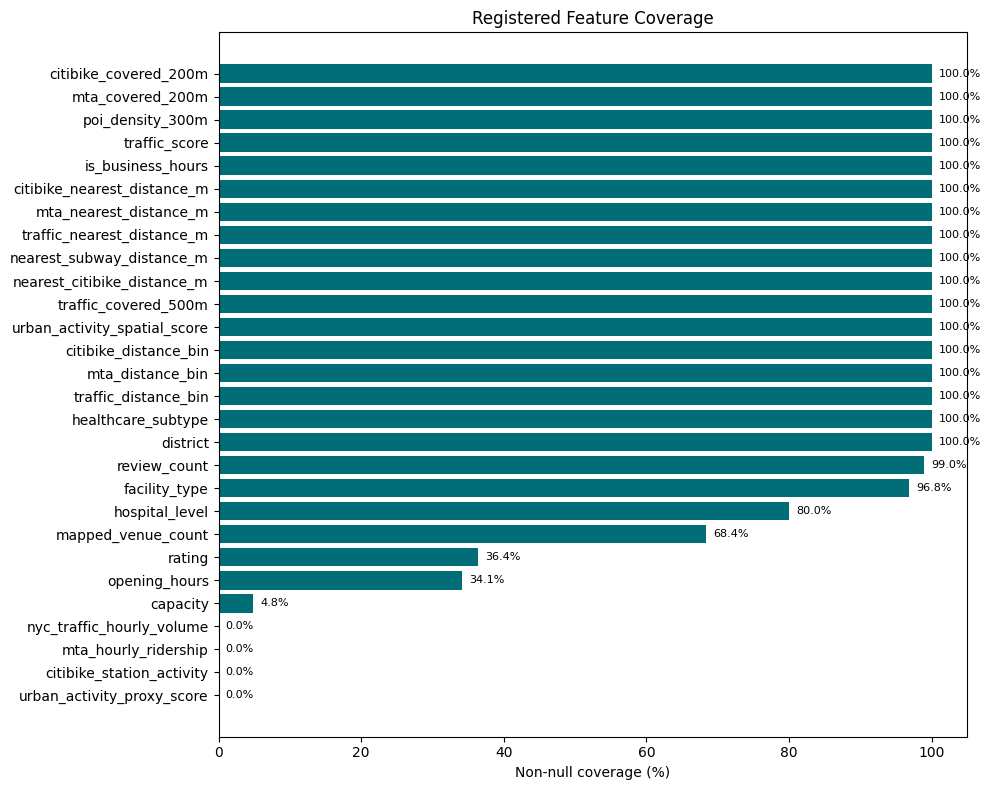

In [33]:

plot_df = feature_coverage.sort_values('coverage_pct', ascending=True)
fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(plot_df['feature'], plot_df['coverage_pct'], color='#006D77')
ax.set_xlabel('Non-null coverage (%)')
ax.set_title('Registered Feature Coverage')
ax.set_xlim(0, 105)
for idx, value in enumerate(plot_df['coverage_pct']):
    ax.text(value + 1, idx, f'{value:.1f}%', va='center', fontsize=8)
plt.tight_layout()
plt.show()


In [8]:

# 静态低覆盖率特征来源溯源：venue 级口径，避免按 7 天小时样本重复计数。
low_cov_features = ['capacity', 'icu_capacity', 'cms_hospital_type', 'cms_rating', 'rating', 'opening_hours']
display(venue_feature_coverage[venue_feature_coverage['feature'].isin(low_cov_features)])

cap_venues = training_frame[training_frame['capacity'].notna()][['venue_id', 'place_title', 'prediction_group_id']].drop_duplicates()
print(f"capacity 有值的 venue 数: {len(cap_venues)}")
display(cap_venues)

cap_rows = training_frame[training_frame['capacity'].notna()]
print(f"capacity 有值的训练行数: {len(cap_rows)}")
for vid, grp in cap_rows.groupby('venue_id'):
    print(f"  venue_id={vid}  rows={len(grp)}  days={grp['day_of_week'].nunique()}  hours={grp['hour'].nunique()}")

rating_static = venue_feature_coverage.loc[venue_feature_coverage['feature'].eq('rating')].iloc[0]
print(f"rating venue 级非空: {int(rating_static['non_null_rows'])}/{int(rating_static['total_rows'])} ({rating_static['coverage_pct']:.1f}%)")
print(f"rating 训练行级非空: {training_frame['rating'].notna().sum()}/{len(training_frame)} ({training_frame['rating'].notna().mean()*100:.1f}%)")


,feature,scope,dtype,non_null_rows,total_rows,coverage_pct,status
2,rating,venue_static,float,395,1086,36.4,ok
3,opening_hours,venue_static,category,370,1086,34.1,ok
13,capacity,venue_static,float,52,1086,4.8,ok
14,icu_capacity,venue_static,float,52,1086,4.8,ok
17,cms_hospital_type,venue_static,category,57,1086,5.2,ok
18,cms_rating,venue_static,category,57,1086,5.2,ok


capacity 有值的 venue 数: 4


,venue_id,place_title,prediction_group_id
7645,654b6548607b4d6157b71a80ef5612cef41b,New York Eye and Ear Infirmary of Mount Sinai ...,ChIJFWtGP55ZwokRUoNXrEPdYmI
7646,b5c44d82affbf77588c85d8c5aea3e5549a3,New York Eye and Ear Infirmary of Mount Sinai ...,ChIJFWtGP55ZwokRUoNXrEPdYmI
8293,42192b4980e3fa1b5f39121fad90876a0b25,Downtown Pharmacy,ChIJz383mCJawokRUoZ_t0ZUvwA
8420,f65915d88909a8b328b89cd8e5383a91943a,Memorial Sloan Kettering Cancer Center New Yor...,ChIJBdNursNYwokRqcBjfvi9FiA


capacity 有值的训练行数: 546
  venue_id=42192b4980e3fa1b5f39121fad90876a0b25  rows=126  days=7  hours=18
  venue_id=654b6548607b4d6157b71a80ef5612cef41b  rows=126  days=7  hours=18
  venue_id=b5c44d82affbf77588c85d8c5aea3e5549a3  rows=126  days=7  hours=18
  venue_id=f65915d88909a8b328b89cd8e5383a91943a  rows=168  days=7  hours=24
rating venue 级非空: 395/1086 (36.4%)
rating 训练行级非空: 14307/22645 (63.2%)


## 5. 外部数据源与匹配审计

这里检查 MTA / Citi Bike / DB ramps / NYS / CMS 静态文件是否被成功读取，以及 hospital/capacity 匹配状态。


In [9]:
display(spatial_audit)
display(source_audit)
display(db_feature_source_audit)

match_status = capacity_match_audit['match_status'].value_counts(dropna=False).rename_axis('match_status').reset_index(name='venues')
cms_status = capacity_match_audit['cms_match_status'].value_counts(dropna=False).rename_axis('cms_match_status').reset_index(name='venues')
display(match_status)
display(cms_status)


,source,status,path,rows,venues_total,venues_missing_coordinates
0,MTA Subway Stations,ok,/Users/alex/Documents/COMP47360-Research_Pract...,496,1086,0
1,Citi Bike GBFS station_information,ok,/Users/alex/Documents/COMP47360-Research_Pract...,2412,1086,0
2,db.healthcare_profiles + venues,ok,mysql://clearpath,1086,1086,0
3,db.pedestrian_ramps,ok,mysql://clearpath,23625,1086,0


,source,status,path,rows,latest_as_of_date
0,NYS Health Facility General Information,ok,/Users/alex/Documents/COMP47360-Research_Pract...,2571,NaN
1,NYS 2dbc-sqe7 bed capacity,ok,/Users/alex/Documents/COMP47360-Research_Pract...,217,2026-06-26
2,CMS xubh-q36u Hospital General Information,ok,/Users/alex/Documents/COMP47360-Research_Pract...,191,NaN


,source,matched_method,rows,avg_match_confidence
0,venues,NaN,4838,NaN
1,healthcare_profiles,NaN,1086,NaN
2,pedestrian_ramps,NaN,23625,NaN
3,venue_source_links,NaN,4838,NaN
4,aed_inventory,single_source,3279,0.8
5,nyc_restrooms,single_source,349,0.6
6,nys_health,single_source,431,0.9
7,osm,single_source,655,0.5
8,parks_toilets,single_source,124,0.3


,match_status,venues
0,matched_by_distance_and_name,869
1,no_facility_within_200m,217


,cms_match_status,venues
0,no_high_confidence_name_match,812
1,NaN,217
2,matched_by_name_ny_only,57


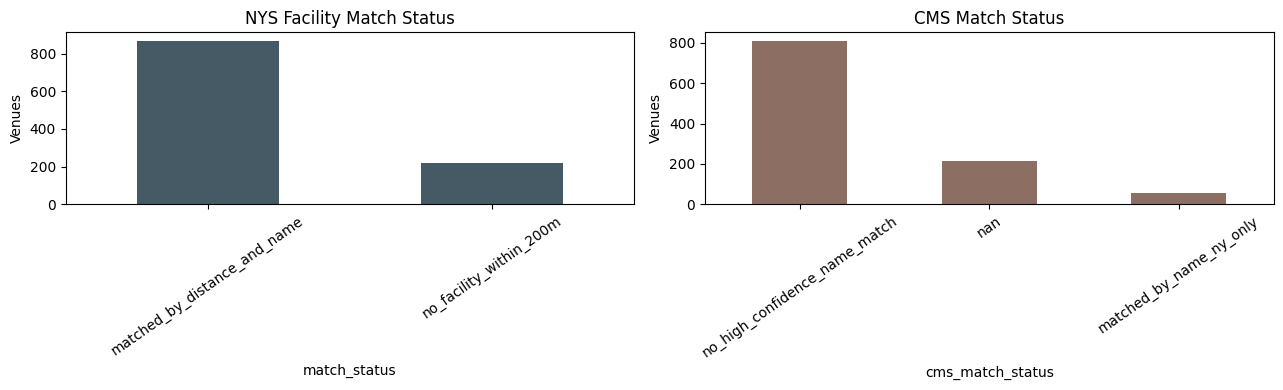

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

match_status.set_index('match_status')['venues'].plot(kind='bar', ax=axes[0], color='#455A64')
axes[0].set_title('NYS Facility Match Status')
axes[0].set_ylabel('Venues')
axes[0].tick_params(axis='x', rotation=35)

cms_status.set_index('cms_match_status')['venues'].plot(kind='bar', ax=axes[1], color='#8D6E63')
axes[1].set_title('CMS Match Status')
axes[1].set_ylabel('Venues')
axes[1].tick_params(axis='x', rotation=35)

plt.tight_layout()
plt.show()


## 5.1 Urban Activity Spatial Features (v1)

These are spatial urban activity proxy features, not live traffic observations.

这些是城市活动空间代理特征，不是实时交通观测。

v1 接入 `6.15-6.20/output/venue_coverage_detail.csv`，使用 Citi Bike / MTA / Traffic 的最近距离和覆盖标记，构建综合空间活动 proxy score。

```text
urban_activity_spatial_score = 0.4 * citibike_score + 0.4 * mta_score + 0.2 * traffic_score
score = max(0, 100 * (1 - distance_m / 500))
缺失距离记为 0 分
```

v2 暂不实现：`mta_hourly_ridership` / `citibike_station_activity` / `nyc_traffic_hourly_volume` / `urban_activity_proxy_score`。


### v2 城市活动时序特征（暂未实现）

以下 4 个特征在 `feature_registry` 中标记为 `v2_not_implemented`，当前训练表中**全部为空**：

| 特征 | 说明 | 未实现原因 |
|---|---|---|
| `mta_hourly_ridership` | MTA 地铁站逐小时进站客流指数 | 需接入 MTA SIRI 或 turnstile 逐小时数据源，当前只有静态站点坐标 |
| `citibike_station_activity` | Citi Bike 站点逐小时借还车活跃度 | 需接入 GBFS v2.3 的 `station_status` 逐小时快照，当前只有站点位置 |
| `nyc_traffic_hourly_volume` | NYC 交通流量逐小时指数 | 需接入 NYC DOT 交通传感器实时数据，当前只有静态路段坐标 |
| `urban_activity_proxy_score` | 上述三项的加权综合时序 proxy | 依赖以上三个数据源就绪后才能计算 |

**对模型的影响**：这 4 个特征在训练时会被 `SimpleImputer` 全部填充为常数（0 或中位数），对预测没有区分力。它们被保留在 feature_registry 中是为了明确 v2 的扩展路线图，不影响当前 v1 模型性能。


In [11]:
urban_activity = read_output('urban_activity_spatial_features_v1.csv')
urban_activity_audit = read_output('urban_activity_spatial_features_v1_audit.csv')

display(urban_activity_audit)
print(f"Urban activity features rows: {len(urban_activity)}")
ua_cols = [
    'citibike_nearest_distance_m', 'mta_nearest_distance_m', 'traffic_nearest_distance_m',
    'citibike_covered_200m', 'mta_covered_200m', 'traffic_covered_500m',
    'urban_activity_spatial_score',
]
existing_ua = [c for c in ua_cols if c in urban_activity.columns]
print("\nNon-null coverage:")
print(urban_activity[existing_ua].notna().mean().round(3))
print("\nurban_activity_spatial_score summary:")
print(urban_activity['urban_activity_spatial_score'].describe())

,source,status,path,rows,venues_total,venues_with_coverage_data
0,venue_coverage_detail.csv,ok,/Users/alex/Documents/COMP47360-Research_Pract...,4838,1086,1086


Urban activity features rows: 1086

Non-null coverage:
citibike_nearest_distance_m     1.0
mta_nearest_distance_m          1.0
traffic_nearest_distance_m      1.0
citibike_covered_200m           1.0
mta_covered_200m                1.0
traffic_covered_500m            1.0
urban_activity_spatial_score    1.0
dtype: float64

urban_activity_spatial_score summary:
count    1086.000000
mean       50.630783
std        13.506119
min         0.000000
25%        40.352500
50%        52.720000
75%        60.152500
max        86.710000
Name: urban_activity_spatial_score, dtype: float64


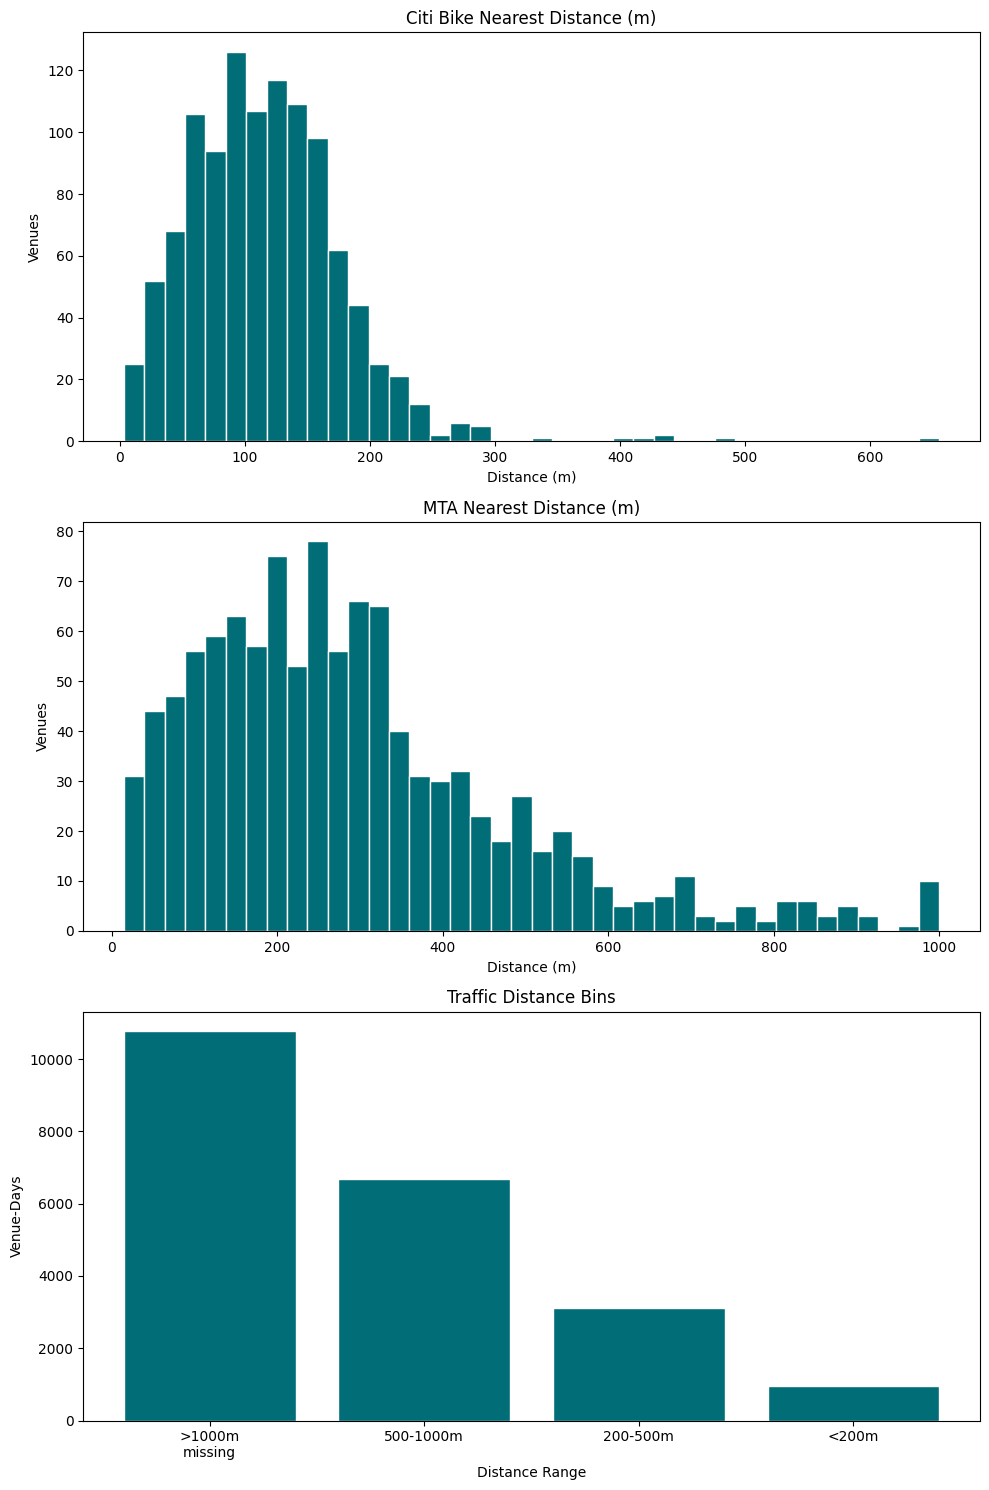

In [28]:

fig, axes = plt.subplots(3, 1, figsize=(10, 15))

# Citi Bike: 原始距离
data = urban_activity['citibike_nearest_distance_m'].dropna()
if len(data):
    axes[0].hist(data.clip(upper=1000), bins=40, color='#006D77', edgecolor='white')
    axes[0].set_title('Citi Bike Nearest Distance (m)')
    axes[0].set_xlabel('Distance (m)')
    axes[0].set_ylabel('Venues')

# MTA: 原始距离
data = urban_activity['mta_nearest_distance_m'].dropna()
if len(data):
    axes[1].hist(data.clip(upper=1000), bins=40, color='#006D77', edgecolor='white')
    axes[1].set_title('MTA Nearest Distance (m)')
    axes[1].set_xlabel('Distance (m)')
    axes[1].set_ylabel('Venues')

# Traffic: 分箱后分布
if 'traffic_distance_bin' in training_frame.columns:
    counts = training_frame['traffic_distance_bin'].value_counts().sort_index()
    axes[2].bar(['>1000m\nmissing', '500-1000m', '200-500m', '<200m'], counts.values, color='#006D77', edgecolor='white')
    axes[2].set_title('Traffic Distance Bins')
    axes[2].set_xlabel('Distance Range')
    axes[2].set_ylabel('Venue-Days')
else:
    data = urban_activity['traffic_nearest_distance_m'].dropna()
    if len(data):
        axes[2].hist(data.clip(upper=1000), bins=40, color='#006D77', edgecolor='white')
        axes[2].set_title('Traffic Nearest Distance (m)')

plt.tight_layout()
plt.show()


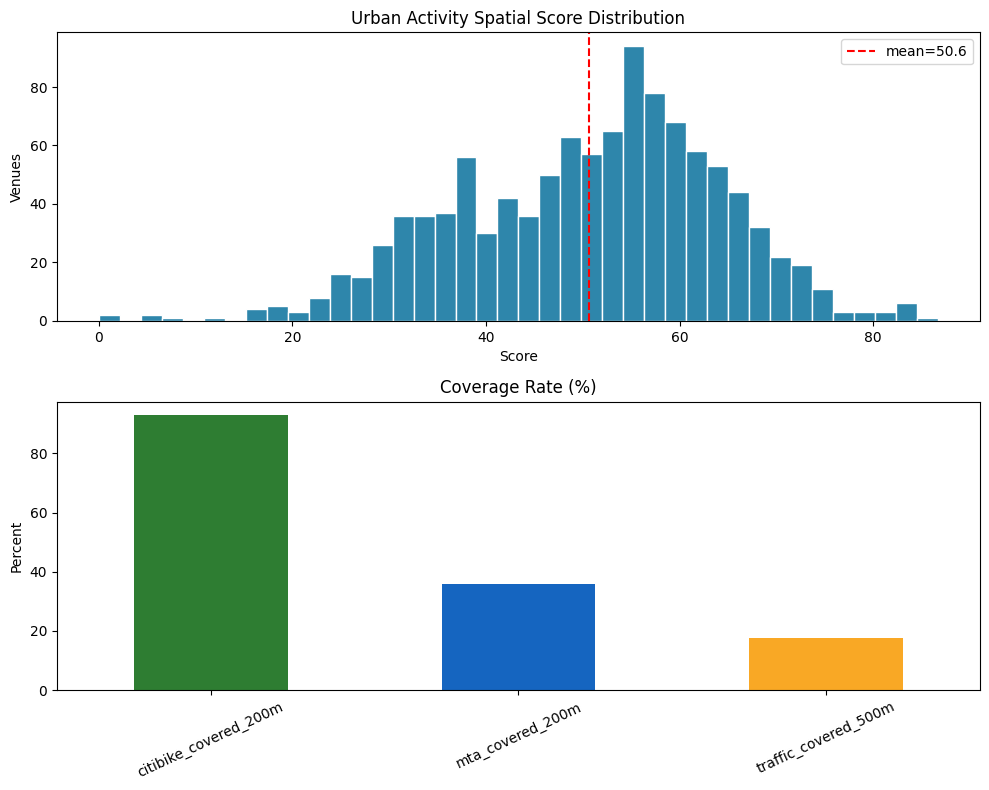

In [34]:

fig, axes = plt.subplots(2, 1, figsize=(10, 8))

score_data = urban_activity['urban_activity_spatial_score'].dropna()
if len(score_data):
    axes[0].hist(score_data, bins=40, color='#2E86AB', edgecolor='white')
    axes[0].set_title('Urban Activity Spatial Score Distribution')
    axes[0].set_xlabel('Score')
    axes[0].set_ylabel('Venues')
    axes[0].axvline(score_data.mean(), color='red', linestyle='--', label=f'mean={score_data.mean():.1f}')
    axes[0].legend()

    coverage_bools = urban_activity[['citibike_covered_200m', 'mta_covered_200m', 'traffic_covered_500m']].apply(pd.to_numeric, errors='coerce').mean() * 100
    coverage_bools.plot(kind='bar', ax=axes[1], color=['#2E7D32', '#1565C0', '#F9A825'])
    axes[1].set_title('Coverage Rate (%)')
    axes[1].set_ylabel('Percent')
    axes[1].tick_params(axis='x', rotation=25)

plt.tight_layout()
plt.show()


## 6. 输入指标与输出指标说明

`role = input_feature` / `input_feature_optional` 是模型输入候选；`target` 是训练标签；`model_output` 是后续前端或模型服务应输出的字段。


In [ ]:
display(io_dictionary)
display(io_dictionary.groupby('source_group').size() .reset_index(name='fields'))


,field,role,source_group,description
0,prediction_group_id,input_key,label_anchor,SerpAPI place id used as leakage-safe group key
1,venue_id,input_key,db_key,DB venue identifier mapped to a prediction group
2,day_of_week,input_feature,popular_times,Typical weekday from Google Popular Times cache
3,hour,input_feature,popular_times,"Hour of day, 0-23"
4,review_count,input_feature,serpapi_label,SerpAPI review count used as venue visibility ...
5,district,input_feature,db_direct,venues.district
6,rating,input_feature,db_direct,"venues.rating, backfilled from SerpAPI Place r..."
7,healthcare_subtype,input_feature,db_direct,healthcare_profiles.healthcare_category
8,opening_hours,input_feature,db_direct,venues.opening_hours
9,nearest_subway_distance_m,input_feature,db_spatial,Distance to nearest MTA subway station in meters


,source_group,fields
0,db_direct,4
1,db_key,1
2,db_spatial,3
3,derived,3
4,external_static,6
5,label_anchor,1
6,label_only,1
7,model_output,4
8,popular_times,2
9,serpapi_label,4


## 7. 训练表与 Baseline 输出样例


In [37]:

from IPython.display import HTML, FileLink

# 带样式的 HTML：固定列宽、自动换行
style = """
<style>
  table { border-collapse: collapse; width: auto; }
  th, td {
    max-width: 120px;
    padding: 4px 6px;
    font-size: 12px;
    word-wrap: break-word;
    white-space: normal;
    border: 1px solid #ddd;
  }
  th { background: #f5f5f5; position: sticky; top: 0; }
  tr:nth-child(even) { background: #fafafa; }
</style>
"""
html_content = style + training_frame.head(10).to_html(max_cols=None, index=False, classes='dataframe')
html_path = OUTPUT_DIR / 'training_frame_sample.html'
html_path.write_text(html_content)
print(FileLink(html_path))

display(seasonal_baseline.head)


/Users/alex/Documents/COMP47360-Research_Practicum/Group6_Summer-Project/Data+ML/test/6.28-7.3/output/training_frame_sample.html


<bound method NDFrame.head of      district day_of_week  hour  baseline_score
0    downtown      friday     0       37.333333
1    downtown      friday     1       26.888889
2    downtown      friday     2       42.444444
3    downtown      friday     3       37.666667
4    downtown      friday     4       46.888889
..        ...         ...   ...             ...
758       NaN   wednesday    19       41.625000
759       NaN   wednesday    20       34.625000
760       NaN   wednesday    21       14.625000
761       NaN   wednesday    22        0.000000
762       NaN   wednesday    23        0.000000

[763 rows x 4 columns]>

## 8. 模型训练、评估与预测曲线

这里展示脚本产出的回归指标、测试集预测样例和 12h 预测曲线。


In [ ]:

display(model_metrics)
sample_preds = model_predictions.groupby('model_name').head(3).sort_values(['model_name', 'hour'])
display(sample_preds[['model_name', 'place_title', 'day_of_week', 'hour', 'busyness_score', 'predicted_score', 'predicted_level', 'serving_predicted_level', 'abs_error']])
display(prediction_curve.head)


,family_name,model_name,split,feature_set,feature_count,mae,rmse,r2,busy_level_accuracy,macro_f1,busy_recall
0,full_available,Ridge,train,"day_of_week,hour,is_weekend,district,review_co...",28,24.796,28.964,0.099,0.470,0.345,0.000
1,full_available,Ridge,val,"day_of_week,hour,is_weekend,district,review_co...",28,25.394,29.971,-0.058,0.421,0.293,0.000
2,full_available,Ridge,test,"day_of_week,hour,is_weekend,district,review_co...",28,25.310,29.428,0.085,0.456,0.327,0.000
3,full_available,RandomForestRegressor,train,"day_of_week,hour,is_weekend,district,review_co...",28,1.893,3.411,0.988,0.953,0.951,0.933
4,full_available,RandomForestRegressor,val,"day_of_week,hour,is_weekend,district,review_co...",28,16.962,22.341,0.412,0.605,0.536,0.224
5,full_available,RandomForestRegressor,test,"day_of_week,hour,is_weekend,district,review_co...",28,20.043,25.748,0.299,0.565,0.541,0.364
6,full_available,GradientBoostingRegressor,train,"day_of_week,hour,is_weekend,district,review_co...",28,14.021,18.077,0.649,0.682,0.612,0.232
7,full_available,GradientBoostingRegressor,val,"day_of_week,hour,is_weekend,district,review_co...",28,17.532,22.225,0.418,0.598,0.498,0.117
8,full_available,GradientBoostingRegressor,test,"day_of_week,hour,is_weekend,district,review_co...",28,18.365,23.202,0.431,0.609,0.552,0.235


,model_name,place_title,day_of_week,hour,busyness_score,predicted_score,predicted_level,serving_predicted_level,abs_error
6096,GradientBoostingRegressor,CVS,sunday,4,25,9.55,quiet,quiet,15.45
6097,GradientBoostingRegressor,CVS,sunday,5,35,9.55,quiet,quiet,25.45
6098,GradientBoostingRegressor,CVS,sunday,6,45,0.00,quiet,quiet,45.00
3048,RandomForestRegressor,CVS,sunday,4,25,10.99,quiet,quiet,14.01
3049,RandomForestRegressor,CVS,sunday,5,35,9.88,quiet,quiet,25.12
3050,RandomForestRegressor,CVS,sunday,6,45,12.33,quiet,quiet,32.67
0,Ridge,CVS,sunday,4,25,37.48,moderate,moderate,12.48
1,Ridge,CVS,sunday,5,35,36.84,moderate,moderate,1.84
2,Ridge,CVS,sunday,6,45,36.21,moderate,moderate,8.79


<bound method NDFrame.head of                    model_name                              venue_id          prediction_group_id day_of_week  hour  predicted_score predicted_level
0                       Ridge  633974e432d8131ed914157259745646f956  ChIJea3I5atZwokRQD9vCPDXlrw      monday     8            46.88        moderate
1                       Ridge  633974e432d8131ed914157259745646f956  ChIJea3I5atZwokRQD9vCPDXlrw      monday     9            46.25        moderate
2                       Ridge  633974e432d8131ed914157259745646f956  ChIJea3I5atZwokRQD9vCPDXlrw      monday    10            45.62        moderate
3                       Ridge  633974e432d8131ed914157259745646f956  ChIJea3I5atZwokRQD9vCPDXlrw      monday    11            44.98        moderate
4                       Ridge  633974e432d8131ed914157259745646f956  ChIJea3I5atZwokRQD9vCPDXlrw      monday    12            44.35        moderate
5                       Ridge  633974e432d8131ed914157259745646f956  ChIJea3I5atZw

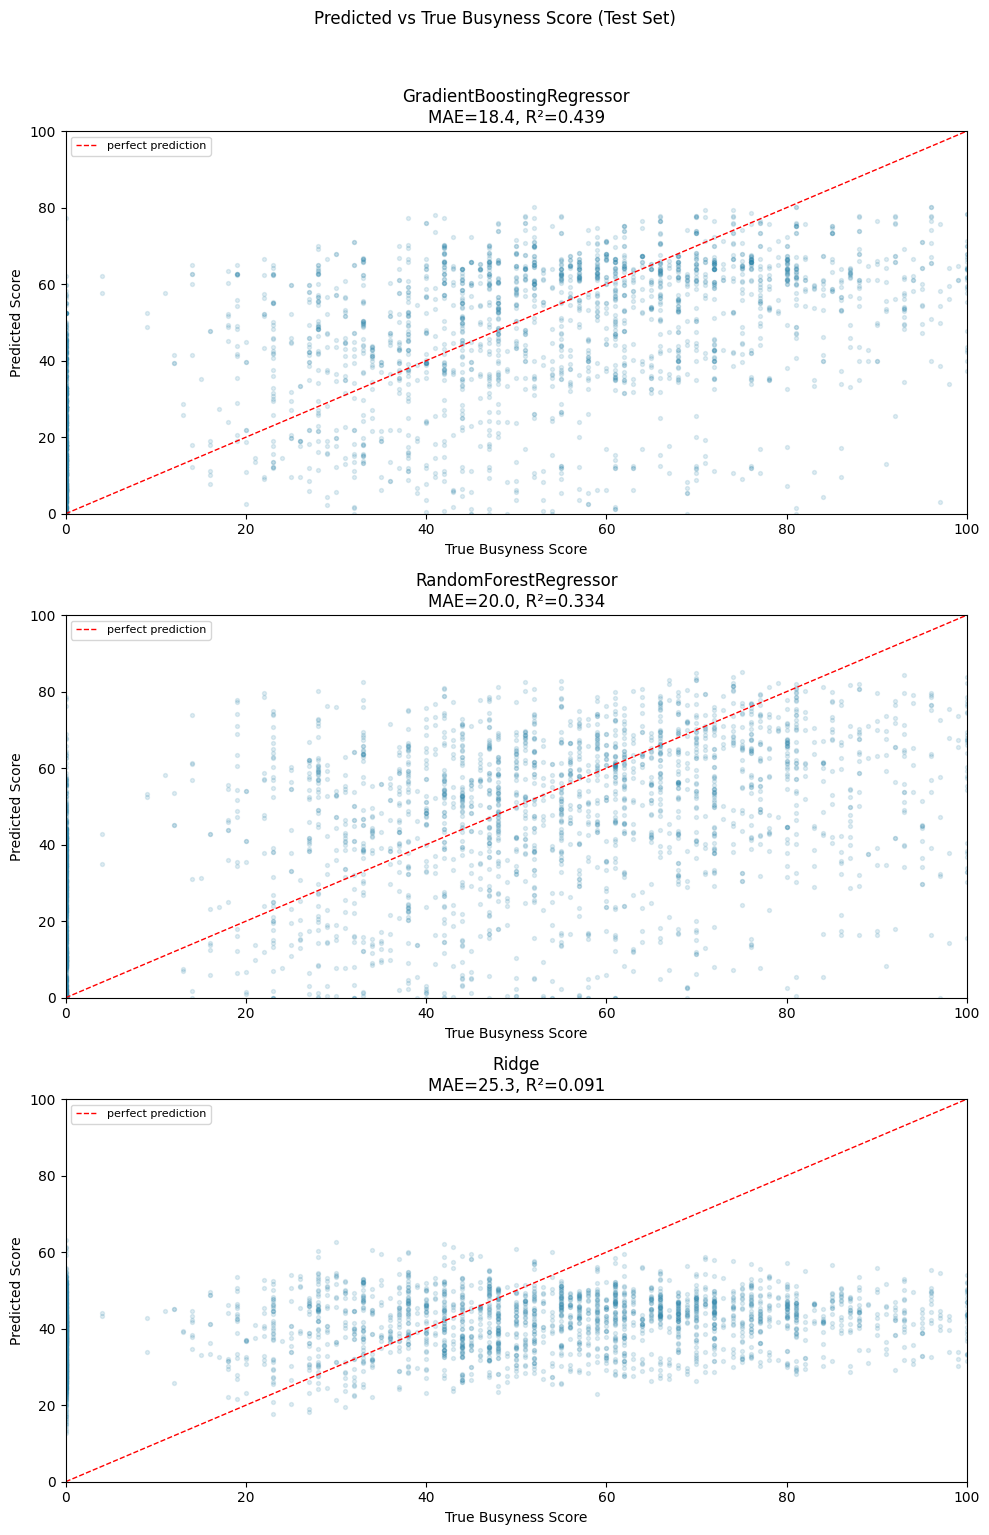

In [57]:

# 预测 vs 真实值散点图：每个模型的预测精度
fig, axes = plt.subplots(3, 1, figsize=(10, 15))
for ax, (model_name, grp) in zip(axes, model_predictions.groupby('model_name')):
    ax.scatter(grp['busyness_score'], grp['predicted_score'], alpha=0.15, s=8, color='#2E86AB')
    ax.plot([0, 100], [0, 100], 'r--', linewidth=1, label='perfect prediction')
    ax.set_xlabel('True Busyness Score')
    ax.set_ylabel('Predicted Score')
    ax.set_title(f'{model_name}\nMAE={grp["abs_error"].mean():.1f}, R²={grp["busyness_score"].corr(grp["predicted_score"])**2:.3f}')
    ax.set_xlim(0, 100)
    ax.set_ylim(0, 100)
    ax.legend(fontsize=8)
plt.suptitle('Predicted vs True Busyness Score (Test Set)', y=1.02)
plt.tight_layout()
plt.show()


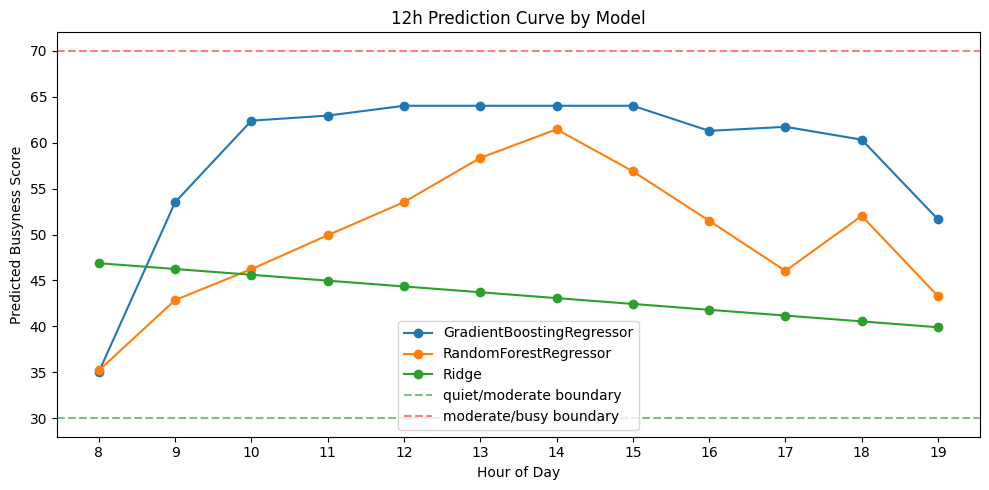

In [38]:

# 预测曲线折线图：每个模型的 12h 预测走势
fig, ax = plt.subplots(figsize=(10, 5))
for model_name, grp in prediction_curve.groupby('model_name'):
    ax.plot(grp['hour'], grp['predicted_score'], marker='o', label=model_name)
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Predicted Busyness Score')
ax.set_title('12h Prediction Curve by Model')
ax.set_xticks(range(8, 20))
ax.axhline(30, color='green', linestyle='--', alpha=0.5, label='quiet/moderate boundary')
ax.axhline(70, color='red', linestyle='--', alpha=0.5, label='moderate/busy boundary')
ax.legend()
plt.tight_layout()
plt.show()


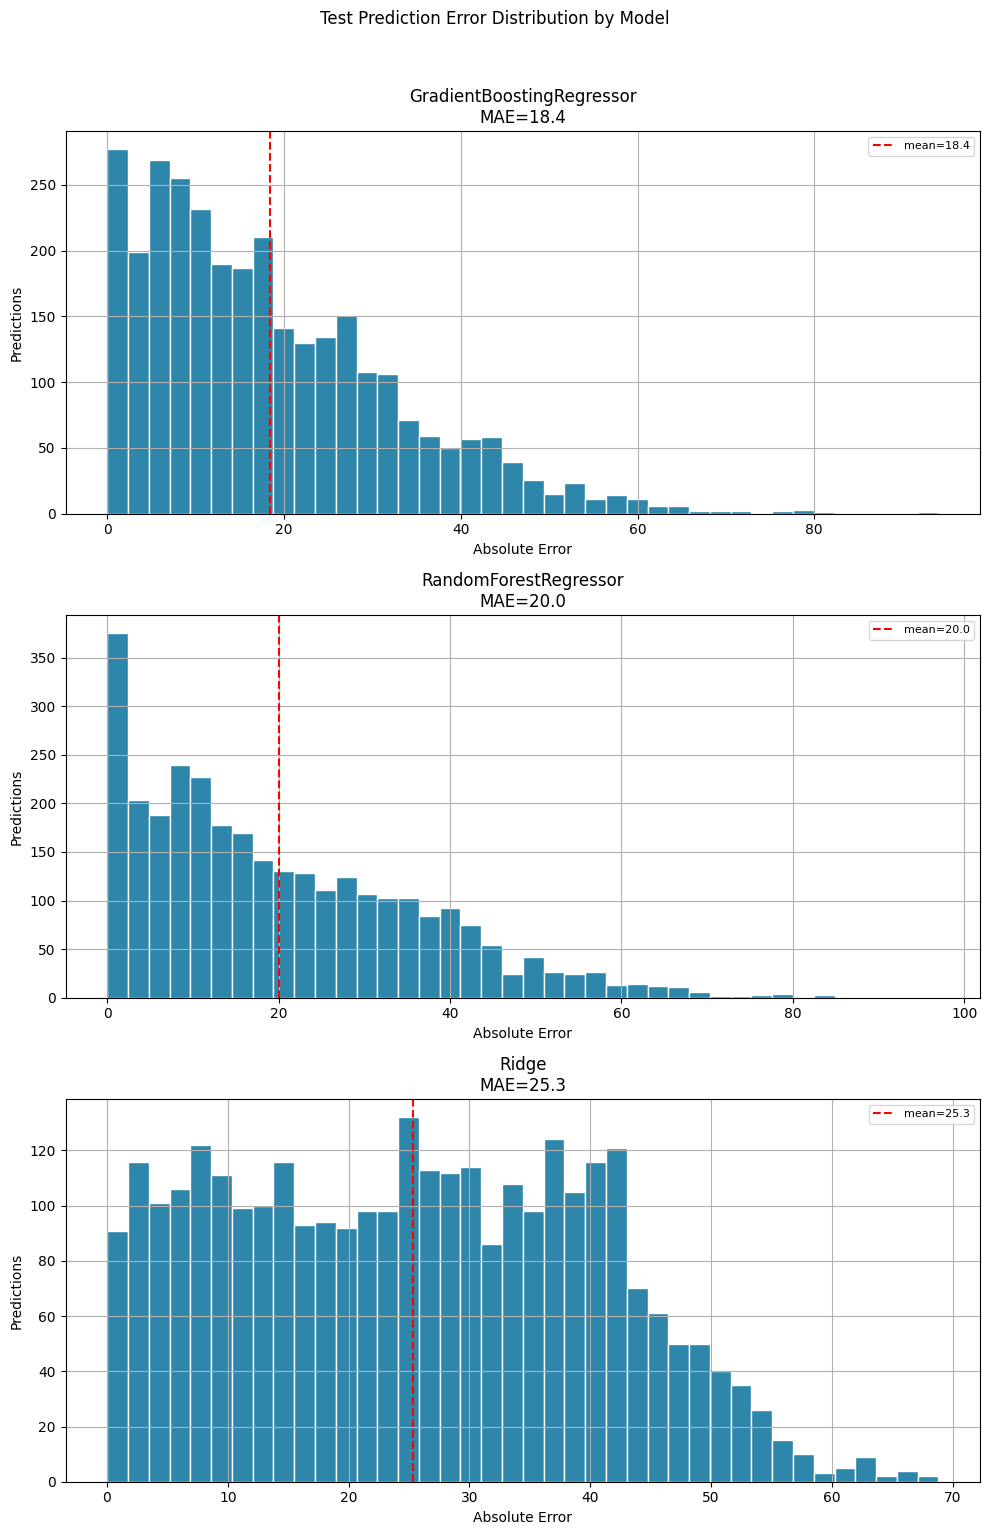

In [47]:
 
# 测试集预测误差分布：每个模型的 abs_error 分布
fig, axes = plt.subplots(3, 1, figsize=(10, 15))
for ax, (model_name, grp) in zip(axes, model_predictions.groupby('model_name')):
    grp['abs_error'].hist(bins=40, ax=ax, color='#2E86AB', edgecolor='white')
    ax.set_title(f'{model_name}\nMAE={grp["abs_error"].mean():.1f}')
    ax.set_xlabel('Absolute Error')
    ax.set_ylabel('Predictions')
    ax.axvline(grp['abs_error'].mean(), color='red', linestyle='--', label=f'mean={grp["abs_error"].mean():.1f}')
    ax.legend(fontsize=8)
plt.suptitle('Test Prediction Error Distribution by Model', y=1.02)
plt.tight_layout()
plt.show()


## 9. 消融结果

这里展示 baseline、空间特征和容量特征的 ablation；缺失源会在表内标记为 `missing_source`。


In [53]:
display(ablation_summary)


,block_name,status,model_name,feature_count,mae,rmse,r2,busy_level_accuracy,macro_f1,busy_recall
0,baseline,ok,Ridge,9,25.531,29.431,0.085,0.461,0.335,0.0
1,mobility,ok,Ridge,11,25.587,29.508,0.080,0.444,0.318,0.0
2,poi_density,ok,Ridge,10,25.444,29.370,0.088,0.465,0.338,0.0
3,capacity,ok,Ridge,18,25.210,29.327,0.091,0.455,0.325,0.0
4,urban_activity_spatial,ok,Ridge,19,25.913,30.067,0.045,0.434,0.313,0.0
5,full_available,ok,Ridge,28,25.310,29.428,0.085,0.456,0.327,0.0


In [20]:
display(low_coverage_imputation.sort_values('coverage_pct'))
display(low_coverage_drop_one.sort_values('delta_mae_vs_capacity_block', ascending=False))


,feature,status,dtype,non_null_rows,total_rows,coverage_pct,impute_strategy,impute_value,post_impute_unique_values,post_impute_top_value_pct
2,capacity,ok,numeric,546,22645,2.4,median,145.0,3,98.1
3,icu_capacity,ok,numeric,546,22645,2.4,median,20.0,2,98.9
6,cms_hospital_type,ok,categorical,612,22645,2.7,most_frequent,Acute Care Hospitals,1,100.0
7,cms_rating,ok,categorical,612,22645,2.7,most_frequent,Not Available,3,99.0
1,opening_hours,ok,categorical,9981,22645,44.1,most_frequent,"Mo-Fr 08:00-20:00; Sa, Su 09:00-17:00",66,59.3
0,rating,ok,numeric,14307,22645,63.2,median,3.5,30,39.0
5,facility_short_type,ok,categorical,15823,22645,69.9,most_frequent,HOSP-EC,10,54.1
4,facility_level,ok,categorical,16537,22645,73.0,most_frequent,Hospital Extension Clinic,13,50.9


,experiment,dropped_feature,status,feature_count,mae,rmse,r2,busy_level_accuracy,macro_f1,busy_recall,delta_mae_vs_capacity_block,delta_r2_vs_capacity_block
7,drop_one_from_capacity_block,cms_rating,ok,17,25.247,29.371,0.088,0.449,0.319,0.0,0.037,-0.003
5,drop_one_from_capacity_block,facility_short_type,ok,17,25.241,29.371,0.088,0.455,0.325,0.0,0.031,-0.003
2,drop_one_from_capacity_block,capacity,ok,17,25.220,29.338,0.090,0.454,0.324,0.0,0.010,-0.001
0,capacity_block,none,ok,18,25.210,29.327,0.091,0.455,0.325,0.0,0.000,0.000
6,drop_one_from_capacity_block,cms_hospital_type,ok,17,25.210,29.327,0.091,0.455,0.325,0.0,0.000,0.000
3,drop_one_from_capacity_block,icu_capacity,ok,17,25.209,29.327,0.091,0.454,0.325,0.0,-0.001,0.000
4,drop_one_from_capacity_block,facility_level,ok,17,25.180,29.313,0.092,0.455,0.325,0.0,-0.030,0.001
1,drop_one_from_capacity_block,rating,ok,17,25.118,29.336,0.091,0.448,0.318,0.0,-0.092,0.000


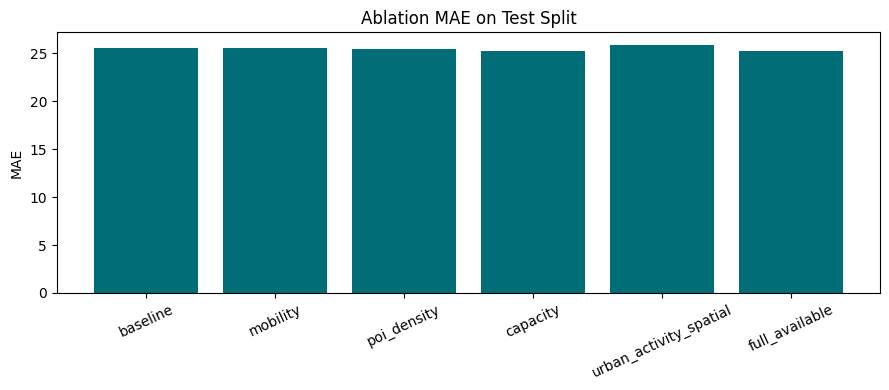

In [21]:
ablation_ok = ablation_summary[ablation_summary['status'].eq('ok')].copy()
if not ablation_ok.empty:
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.bar(ablation_ok['block_name'], ablation_ok['mae'], color='#006D77')
    ax.set_ylabel('MAE')
    ax.set_title('Ablation MAE on Test Split')
    ax.tick_params(axis='x', rotation=25)
    plt.tight_layout()
    plt.show()


### 9.1 Ablation: Urban Activity Spatial vs Baseline

对比 baseline / mobility / urban_activity_spatial / full_available 四组消融结果。

,block_name,status,model_name,feature_count,mae,rmse,r2,macro_f1
0,baseline,ok,Ridge,9,25.531,29.431,0.085,0.335
1,mobility,ok,Ridge,11,25.587,29.508,0.080,0.318
4,urban_activity_spatial,ok,Ridge,19,25.913,30.067,0.045,0.313
5,full_available,ok,Ridge,28,25.310,29.428,0.085,0.327


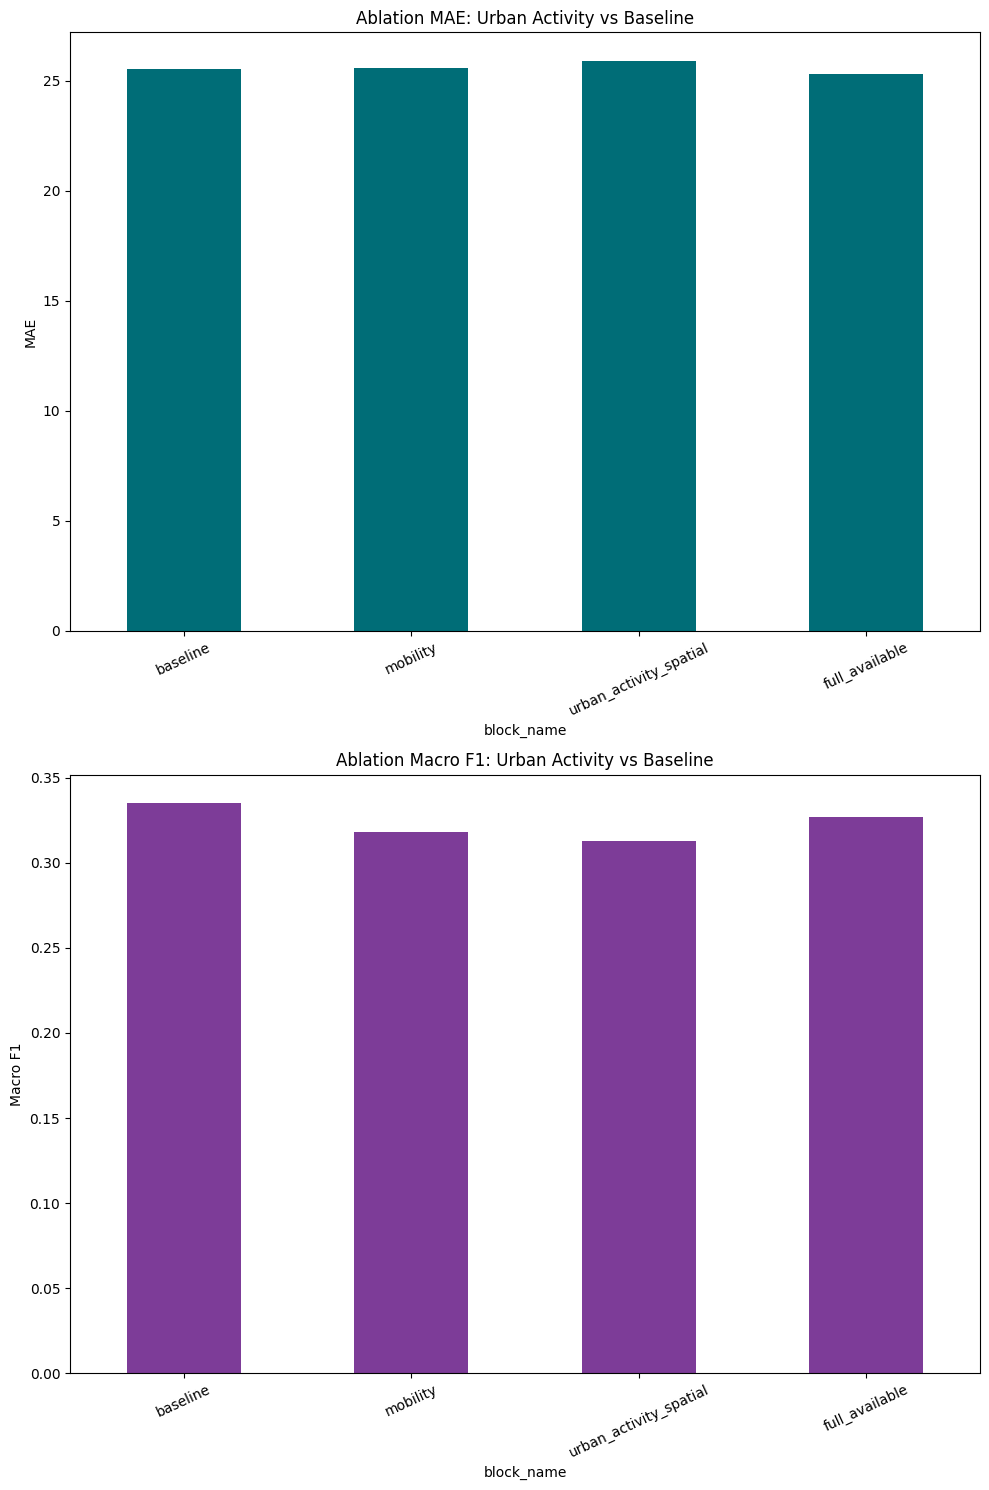

In [54]:
compare_blocks = ['baseline', 'mobility', 'urban_activity_spatial', 'full_available']
ablation_compare = ablation_summary[ablation_summary['block_name'].isin(compare_blocks)].copy()
display(ablation_compare[['block_name', 'status', 'model_name', 'feature_count', 'mae', 'rmse', 'r2', 'macro_f1']])

ok_compare = ablation_compare[ablation_compare['status'].eq('ok')]
if not ok_compare.empty:
    fig, axes = plt.subplots(2, 1, figsize=(10, 15))
    ok_compare.set_index('block_name')['mae'].plot(kind='bar', ax=axes[0], color='#006D77')
    axes[0].set_title('Ablation MAE: Urban Activity vs Baseline')
    axes[0].set_ylabel('MAE')
    axes[0].tick_params(axis='x', rotation=25)
    ok_compare.set_index('block_name')['macro_f1'].plot(kind='bar', ax=axes[1], color='#7D3C98')
    axes[1].set_title('Ablation Macro F1: Urban Activity vs Baseline')
    axes[1].set_ylabel('Macro F1')
    axes[1].tick_params(axis='x', rotation=25)
    plt.tight_layout()
    plt.show()

## 10. 输出文件清单

这些文件是当前 notebook 的主要产物，可供后续模型训练、前端样例和汇报引用。


In [23]:
manifest


,name,path,rows
0,status_breakdown,/Users/alex/Documents/COMP47360-Research_Pract...,3
1,coverage_summary,/Users/alex/Documents/COMP47360-Research_Pract...,1
2,feature_registry,/Users/alex/Documents/COMP47360-Research_Pract...,28
3,popular_times,/Users/alex/Documents/COMP47360-Research_Pract...,16090
4,popular_times_summary,/Users/alex/Documents/COMP47360-Research_Pract...,1
5,place_features,/Users/alex/Documents/COMP47360-Research_Pract...,490
6,spatial_features,/Users/alex/Documents/COMP47360-Research_Pract...,1086
7,spatial_audit,/Users/alex/Documents/COMP47360-Research_Pract...,4
8,urban_activity_features,/Users/alex/Documents/COMP47360-Research_Pract...,1086
9,urban_activity_audit,/Users/alex/Documents/COMP47360-Research_Pract...,1


## 11. 仍需注意

- `busyness_score` 是 Google Popular Times weak label，不是真实 foot traffic。
- split 必须按 `prediction_group_id` 分组，禁止 hourly rows 随机切分。
- `capacity` / `cms_rating` 覆盖率低是正常现象，因为并非所有 healthcare venue 都是医院。
- `is_business_hours` 已从 SerpAPI per-day hours 解析；第一版只用于 serving/post-processing 截断，非营业时间输出 `no_data`。
